# 04 — Locomotor resilience

Quantifies the impact of the sand perturbation by comparing **inside-the-sand-bed** metrics with **other corridor passages** (baseline).

## Method (hybrid bbox + PCA)

1. Compute 3 resilience signals from the vertical sacrum trace:
   - `sig_var`     — rolling variance (1 s window) → vertical variability
   - `sig_radius`  — phase-space radius (distance to TDE centroid) → dynamic dispersion
   - `sig_cadence` — local dominant frequency (Welch) → instantaneous cadence
2. **Perturbation** = longest bbox segment (precise, median error ≈ 0 s vs CRF)
3. **Baseline** = other corridor passages detected via PCA-calibrated corridor (statistically valid: same circuit phase as perturbation)
4. Per-trial metrics: `z_var`, `z_radius`, `ratio_var`, `ratio_radius`, `delta_cadence_hz`

Exploitability criterion: at least 3 valid baseline passages, otherwise the trial is recorded with NaN metrics.

## Inputs / Outputs

- **Inputs**  : `data/processed/*.npz`, `outputs/tables/03_tde_per_participant.csv`
- **Outputs** : `outputs/tables/04_resilience_metrics.csv`, `outputs/figures/04_metrics_by_condition.png`, `outputs/figures/04_individual_trajectories.png`

In [2]:
from resilience import paths
from resilience.analysis import resilience_workflow
from resilience.viz import plots

from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline

OUT_FIGURES = Path(paths.OUTPUTS_DIR) / 'figures'

## 1. Run pipeline

In [3]:
tde_params = resilience_workflow.load_tde_params()
trials     = resilience_workflow.load_all_trials()

print(f"\n✅ {len(trials)} trials loaded")

C:\Users\etulyon1\Documents\PYTHON-R-GIT\1_Projects\resilience-locomotor-aging-RAS_v2\src\resilience\analysis\resilience_workflow.py:125: RuntimeWarning: Mean of empty slice
  sacrum_xy = np.nanmean(dos_xy, axis=0)


  ✅ 46 trials loaded

✅ 46 trials loaded


In [4]:
df_res, signals_cache = resilience_workflow.compute_metrics(trials, tde_params)
print(f"\n✅ {len(df_res)} trials analysed")
df_res

C:\Users\etulyon1\Documents\PYTHON-R-GIT\1_Projects\resilience-locomotor-aging-RAS_v2\src\resilience\analysis\resilience_workflow.py:289: RuntimeWarning: Mean of empty slice
  bcads.append(float(np.nanmean(signals['sig_cadence'][msk])))



✅ 46 trials analysed


,participant,condition,n_baseline_passages,pert_duration_s,pert_var,pert_radius,pert_cadence,baseline_var,baseline_radius,baseline_cadence,z_var,z_radius,ratio_var,ratio_radius,delta_cadence_hz
0,001CrMa,silence,21,4.86,168.68,26.66,1.617,140.75,23.91,2.000,1.23,1.45,1.20,1.11,-0.383
1,001CrMa,tempo_random,21,4.35,266.17,35.49,1.680,172.54,26.15,2.000,2.93,3.75,1.54,1.36,-0.320
2,001CrMa,beatmove_adaptatif,17,4.18,309.51,36.46,1.849,181.68,27.13,2.000,3.42,3.39,1.70,1.34,-0.151
3,002CrPa,silence,19,4.96,123.83,23.93,1.000,92.43,19.28,1.998,4.01,5.33,1.34,1.24,-0.998
4,002CrPa,beatmove_adaptatif,15,4.93,143.78,24.72,1.108,83.91,18.79,1.791,5.61,5.43,1.71,1.32,-0.683
5,002CrPa,tempo_random,17,4.95,166.46,27.56,1.349,75.56,17.32,1.954,8.91,7.00,2.20,1.59,-0.604
6,003BrLu,silence,22,3.97,182.63,27.35,1.970,146.15,24.33,1.776,1.57,1.49,1.25,1.12,0.194
7,003BrLu,tempo_random,18,3.84,405.37,43.09,1.693,211.41,29.40,1.589,5.93,5.55,1.92,1.47,0.104
8,003BrLu,beatmove_adaptatif,24,3.91,293.64,34.13,1.299,199.90,28.65,2.000,4.96,3.49,1.47,1.19,-0.701
9,004CaGe,silence,22,3.93,277.00,34.50,1.746,150.97,24.79,2.000,9.16,7.64,1.83,1.39,-0.254


## 2. Descriptive stats per condition

In [5]:
metric_cols = ['z_var', 'z_radius', 'ratio_var', 'ratio_radius', 'delta_cadence_hz']
for col in metric_cols:
    print(f"\n--- {col} ---")
    print(df_res.groupby('condition')[col].describe()[['count', '25%', '50%', '75%']].round(2))


--- z_var ---
                    count   25%   50%   75%
condition                                  
beatmove_adaptatif   15.0  1.84  4.21  6.30
silence              15.0  2.51  4.17  6.79
tempo_random         16.0  3.42  5.42  8.02

--- z_radius ---
                    count   25%   50%   75%
condition                                  
beatmove_adaptatif   15.0  2.34  3.92  5.40
silence              15.0  1.58  3.70  6.48
tempo_random         16.0  2.98  5.46  7.25

--- ratio_var ---
                    count   25%   50%   75%
condition                                  
beatmove_adaptatif   15.0  1.27  1.47  1.74
silence              15.0  1.23  1.41  1.54
tempo_random         16.0  1.45  1.56  1.82

--- ratio_radius ---
                    count   25%   50%   75%
condition                                  
beatmove_adaptatif   15.0  1.16  1.25  1.35
silence              15.0  1.15  1.22  1.32
tempo_random         16.0  1.24  1.37  1.43

--- delta_cadence_hz ---
                    

## 3. Plots

   ✅ Figure saved: C:\Users\etulyon1\Documents\PYTHON-R-GIT\1_Projects\resilience-locomotor-aging-RAS_v2\outputs\figures\04_metrics_by_condition.png


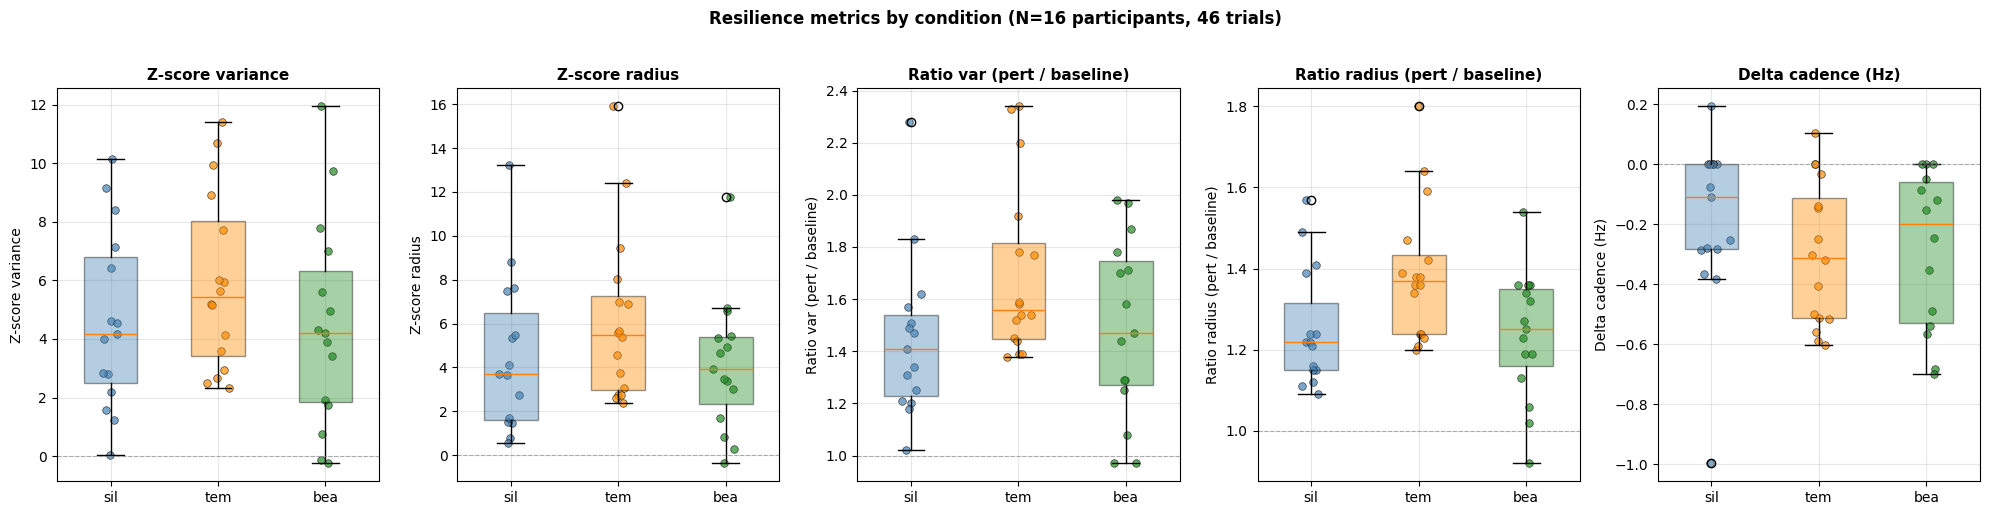

In [6]:
plots.plot_resilience_boxplots(df_res,
    save_to=OUT_FIGURES / '04_metrics_by_condition.png')
plt.show()

   ✅ Figure saved: C:\Users\etulyon1\Documents\PYTHON-R-GIT\1_Projects\resilience-locomotor-aging-RAS_v2\outputs\figures\04_individual_trajectories.png


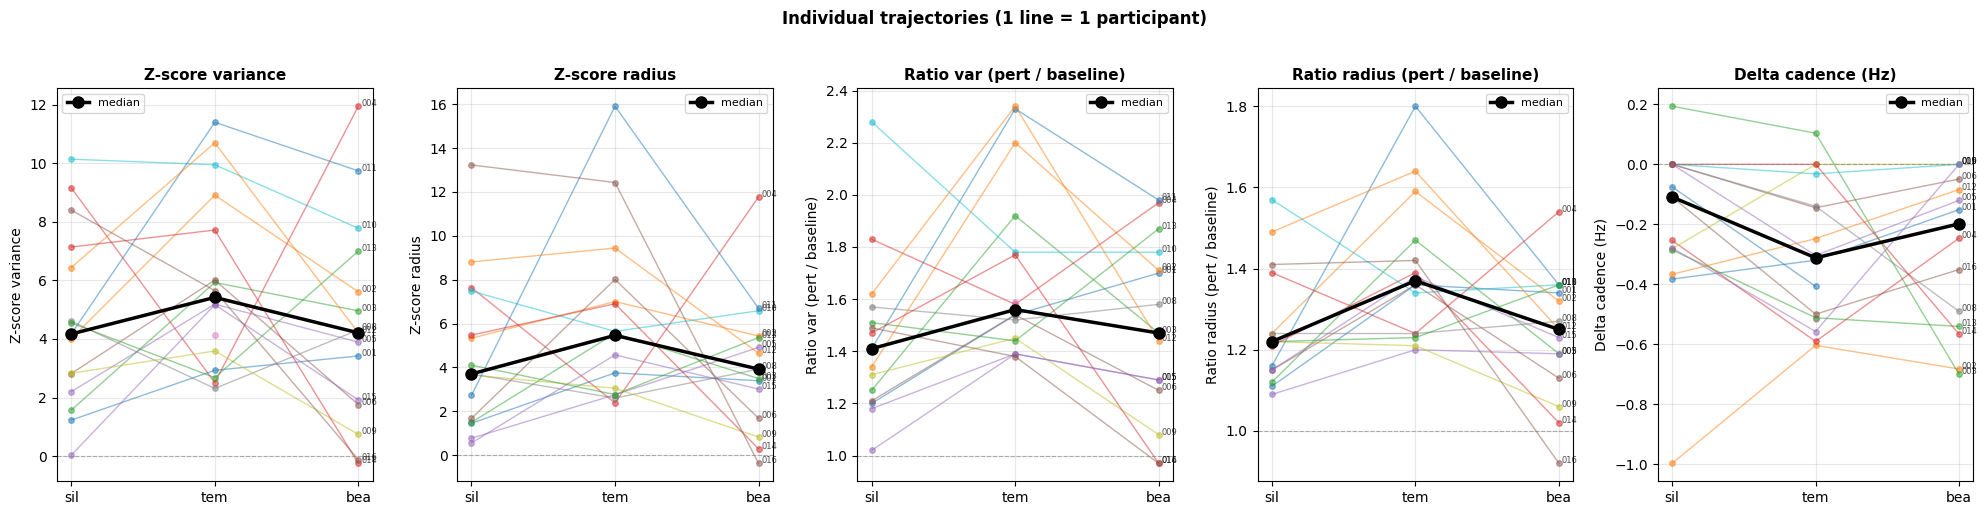

In [7]:
plots.plot_resilience_individual_trajectories(df_res,
    save_to=OUT_FIGURES / '04_individual_trajectories.png')
plt.show()

## 4. Export

In [8]:
out_path = resilience_workflow.export(df_res)
n_complete = df_res[metric_cols].notna().all(axis=1).sum()
print(f"✅ Exported: {out_path}")
print(f"   {len(df_res)} trials, {df_res['participant'].nunique()} participants")
print(f"   {n_complete} trials with all 5 metrics valid")

✅ Exported: C:\Users\etulyon1\Documents\PYTHON-R-GIT\1_Projects\resilience-locomotor-aging-RAS_v2\outputs\tables\04_resilience_metrics.csv
   46 trials, 16 participants
   45 trials with all 5 metrics valid


In [9]:
import numpy as np
from resilience.paths import processed_file
from resilience.participants import get_trial
from resilience import config
from resilience.processing import detection

code, cond = '012WaCh', 'silence'  # essai qui marche, n=31 segments

with np.load(processed_file(code, cond), allow_pickle=True) as z:
    dos = np.stack([z[f'raw_Dos0{i}'] for i in (1,2,3,4)], axis=0)
    print(f"raw_Dos shape: {dos.shape}  (= {dos.shape[1]/400:.1f}s at 400Hz)")
    sig_final = z['signal_final']
    print(f"signal_final shape: {sig_final.shape}  (= {sig_final.shape[0]/100:.1f}s at 100Hz)")

sacrum_xy = np.nanmean(dos[..., :2], axis=0)
trial = get_trial(code, cond)
print(f"\ncrop_start_s = {trial.crop_start_s}")
print(f"Expected: raw_Dos length = full session = {sig_final.shape[0]/100 + trial.crop_start_s:.1f}s = {int((sig_final.shape[0]/100 + trial.crop_start_s)*400)} samples raw")
print(f"Actual raw_Dos: {dos.shape[1]} samples")
print()

# Run BBOX baseline
res = detection.detect_sand_by_bbox(
    sacrum_xy,
    corners=config.BAC_BASELINE_LEFT_CORNERS_MM,
    margin_mm=config.BAC_BASELINE_LEFT_MARGIN_MM,
    min_duration_s=0.5,
)
print(f"BBOX returned {res['n_segments']} segments")
print(f"First 5 segments (sample indices i0, i1):")
for i, (i0, i1) in enumerate(res['segments'][:5]):
    print(f"  seg {i}: i0={i0}, i1={i1}  -> in seconds (if /400): {i0/400:.1f}-{i1/400:.1f}s")

raw_Dos shape: (4, 168000, 3)  (= 420.0s at 400Hz)
signal_final shape: (42000,)  (= 420.0s at 100Hz)

crop_start_s = 60.0
Expected: raw_Dos length = full session = 480.0s = 192000 samples raw
Actual raw_Dos: 168000 samples

BBOX returned 32 segments
First 5 segments (sample indices i0, i1):
  seg 0: i0=2680, i1=4161  -> in seconds (if /400): 6.7-10.4s
  seg 1: i0=7943, i1=9283  -> in seconds (if /400): 19.9-23.2s
  seg 2: i0=13071, i1=14565  -> in seconds (if /400): 32.7-36.4s
  seg 3: i0=18237, i1=19582  -> in seconds (if /400): 45.6-49.0s
  seg 4: i0=23078, i1=24610  -> in seconds (if /400): 57.7-61.5s


C:\Users\etulyon1\AppData\Local\Temp\ipykernel_7504\1702518896.py:15: RuntimeWarning: Mean of empty slice
  sacrum_xy = np.nanmean(dos[..., :2], axis=0)
